In [20]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [1]:
# Carrega os dados do CSV   . Delimiter=',' indica que as colunas são separadas por virgula
# skiprows=2 para pular as duas linhas de cabeçalho/comentário
# usecols para que o código não confunca as pipes | antes dos números, deixando uma coluna vazia
dataset = np.loadtxt("knn_dataset_exercicio_2.csv", delimiter='|', skiprows=2, usecols=(1, 2, 3))

# separa as colunas de características (features) e a coluna de rótulos (labels)
# X_train recebe todas as linhas, mas apenas as duas primeiras colunas (indice 0 e 1)
X_train = dataset[:, :2]

# y_train recebe todas as linhas, mas apenas a última coluna (indice2)
# .astype(int) para garantir que as classes sejam tratadas como inteiros
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos(y_train):")
print(y_train[:5])

NameError: name 'np' is not defined

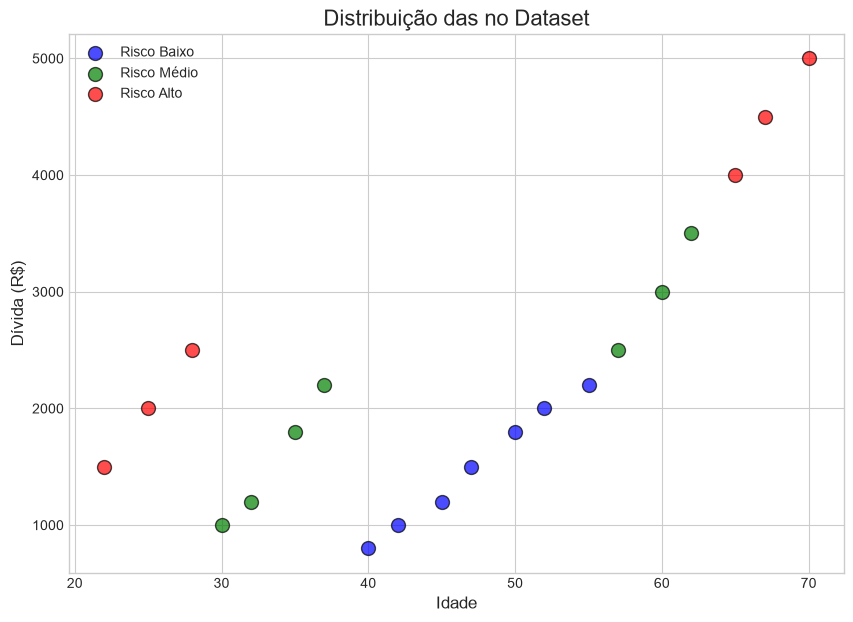

In [29]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# plota a classe 1
ax.scatter(X_train[y_train == 1, 0], X_train[y_train ==1, 1],
           c='blue', s=100, edgecolors='k', alpha=0.7, label='Risco Baixo')

# plota a classe 2
ax.scatter(X_train[y_train == 2, 0], X_train[y_train ==2, 1],
           c='green', s=100, edgecolors='k', alpha=0.7, label='Risco Médio')

# plota os pontos benignos (Classe 1)
ax.scatter(X_train[y_train == 3, 0], X_train[y_train ==3, 1],
           c='red', s=100, edgecolors='k', alpha=0.7, label='Risco Alto')

ax.set_title('Distribuição das no Dataset', fontsize=16)
ax.set_xlabel('Idade', fontsize=12)
ax.set_ylabel('Dívida (R$)', fontsize=12)
ax.legend()
plt.show()

In [23]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

In [24]:
def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos proximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena as distancias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # CORREÇÃO AQUI: pega o indice 1 (a classe) de cada tupla 'd'
    vizinhos = [d[1] for d in distancias[:k]]
    return vizinhos

In [25]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritario dos vizinhos"""
    
    # conta a ocorrencia de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)

    # retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

In [35]:
# Exemplo de novo cliente: idade, dívida
novo_cliente = np.array([50, 1000])
k = 3  # ou 5
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_cliente, k)
previsao_final = prever_classificacao(vizinhos_proximos)
print(f"Novo cliente: Idade={novo_cliente[0]}, Dívida={novo_cliente[1]}")
print(f"Valor de k: {k}")
print(f"Classes dos {k} vizinhos mais próximos: {vizinhos_proximos}")
print("----------------------------------------------------------")
if previsao_final == 3:
    print(f"--> Previsão final: Risco Alto")
elif previsao_final== 2:
    print(f"--> Previsão final: Risco Médio")
else:
    print('--> Previsão final:Risco Baixo')

Novo cliente: Idade=50, Dívida=1000
Valor de k: 3
Classes dos 3 vizinhos mais próximos: [np.int64(1), np.int64(2), np.int64(1)]
----------------------------------------------------------
--> Previsão final:Risco Baixo


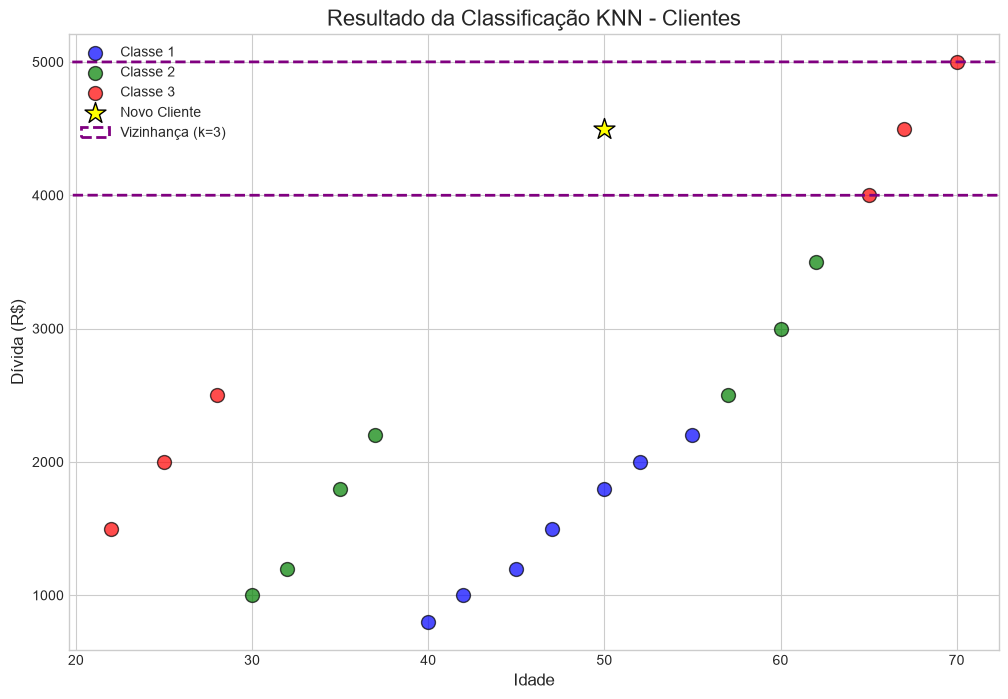

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plota os dados de treino com as 3 classes
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', s=100, edgecolor='k', alpha=0.7, label='Classe 1')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1], c='green', s=100, edgecolor='k', alpha=0.7, label='Classe 2')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1], c='red', s=100, edgecolor='k', alpha=0.7, label='Classe 3')

# Plota o novo ponto
ax.scatter(novo_cliente[0], novo_cliente[1], c='yellow', s=250, edgecolor='k', marker='*', label='Novo Cliente')

# Destaque para o círculo de vizinhos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_cliente) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]
distancia_maxima = calcular_distancia_euclidiana(novo_cliente, pontos_vizinhos[-1])

circulo = plt.Circle(novo_cliente, distancia_maxima, color='purple', fill=False, linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

ax.set_title('Resultado da Classificação KNN - Clientes', fontsize=16)
ax.set_xlabel('Idade', fontsize=12)
ax.set_ylabel('Dívida (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()


A) Sim. No dataset fornecido, os dados apresentam uma clara correlação positiva e linear entre Renda_Mensal e Gasto_Mensal. As classes estão distribuídas em faixas bem definidas e sem sobreposição

B) Sim, podem ser classificados incorretamente

C) 